# CHAPTER 3 - Exploring Financial Time Series Data

In [45]:
#Visualization settings 
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    context="talk",
    style="whitegrid",
    palette="colorblind",
    rc={"figure.figsize": [12, 8]}
)

In [49]:
#Let's check if our notebook was save it correctly 
import os

os.getcwd()

'/Users/dulcedelapazortiz/Documents/ Python_Projects/Python for finance '

In [50]:
os.listdir()

['credit_card_default.csv',
 'Untitled5.ipynb',
 'Untitled1.ipynb',
 'chapter_1.ipynb',
 'chapter_3.ipynb',
 'Exploring-Financial-Time-Series.ipynb',
 'Untitled3.ipynb',
 'Untitled.ipynb',
 'mxn_forecasting_clean.csv',
 'chapter_2.ipynb',
 'Untitled2.ipynb',
 'Adquiring_data.ipynb',
 'Data_preprocessing.ipynb',
 '.ipynb_checkpoints']

In [90]:
#let's bring out clean dataset to our new notebook
import pandas as pd

df_final = pd.read_csv(
    "mxn_forecasting_clean.csv",
    index_col=0,
    parse_dates=True
)

df_final.head()

,mxn_usd,oil_prices,usd_mxn_returns,oil_returns,vix,fed_funds_rate,industrial_activity,inflation_rate,banxico_rate
2008-01-22,10.925,89.64,NaN,NaN,31.010000,3.94,100.9807,3.704372,7.5
2008-01-23,10.893,87.65,-0.002933,-0.022450,29.020000,3.94,100.9807,3.704372,7.5
2008-01-24,10.862,89.98,-0.002850,0.026236,27.780001,3.94,100.9807,3.704372,7.5
2008-01-25,10.866,90.37,0.000368,0.004325,29.080000,3.94,100.9807,3.704372,7.5
2008-01-28,10.863,90.99,-0.000276,0.006837,27.780001,3.94,100.9807,3.704372,7.5


### 1. Summary Statistics

In [52]:
df_final.describe().T

,count,mean,std,min,25%,50%,75%,max
mxn_usd,4246.0,16.414700,3.414322,9.866500,13.047947,17.113894,19.338048,25.336201
oil_prices,4246.0,72.993224,22.686653,-36.980000,53.462500,72.965000,90.887500,145.310000
usd_mxn_returns,4245.0,0.000150,0.008510,-0.068911,-0.004404,-0.000175,0.004267,0.092886
oil_returns,4243.0,0.000120,0.028817,-0.281382,-0.012408,0.000828,0.012926,0.425832
vix,4246.0,19.973933,9.129960,9.140000,13.910000,17.500000,22.954999,82.690002
fed_funds_rate,4246.0,1.191858,1.649567,0.050000,0.100000,0.190000,1.910000,5.330000
industrial_activity,4246.0,98.369914,4.582475,82.542900,96.756900,99.661700,101.277300,106.086000
inflation_rate,4246.0,4.572199,1.438301,2.130778,3.496704,4.323979,5.566181,8.699756
banxico_rate,4246.0,6.047398,2.475351,3.000000,4.250000,4.750000,7.750000,11.250000


Note:

The Mexican peso returns exhibit an average close to zero, as commonly observed in financial return series, although the large minimum and maximum values indicate episodes of substantial exchange-rate volatility associated with major economic shocks.

Oil returns also fluctuate around zero but display considerable dispersion, reflecting the sensitivity of global energy markets to supply and demand disruptions. 

The VIX index averages approximately 20 points but reaches a maximum value of 82.69, indicating extreme levels of global financial uncertainty during the COVID-19 crisis. 

Industrial activity shows meaningful variation over time, capturing fluctuations in Mexico's business cycle.

Finally, both the Federal Funds Rate and the Banxico policy rate exhibit substantial changes throughout the sample period, reflecting different monetary policy regimes and macroeconomic conditions.

### 2. Correlation Matrix

In [34]:
corr = df_final.corr()

corr

,usd_mxn_returns,oil_returns,vix,fed_funds_rate,industrial_activity,inflation_rate,banxico_rate
usd_mxn_returns,1.000000,-0.197091,0.094230,-0.002825,0.013799,-0.016266,-0.001218
oil_returns,-0.197091,1.000000,-0.070556,-0.012493,-0.049437,-0.015664,-0.011588
vix,0.094230,-0.070556,1.000000,-0.164812,-0.498457,0.162673,0.047514
fed_funds_rate,-0.002825,-0.012493,-0.164812,1.000000,0.350549,0.310418,0.919894
industrial_activity,0.013799,-0.049437,-0.498457,0.350549,1.000000,0.070228,0.207998
inflation_rate,-0.016266,-0.015664,0.162673,0.310418,0.070228,1.000000,0.482454
banxico_rate,-0.001218,-0.011588,0.047514,0.919894,0.207998,0.482454,1.000000


Note: 
The exchange rate is expressed as MXN/USD, representing the number of Mexican pesos required to purchase one U.S. dollar. Therefore, an increase in the exchange rate indicates a depreciation of the Mexican peso, while a decrease indicates an appreciation. 


### 3. Correlation Heatmap

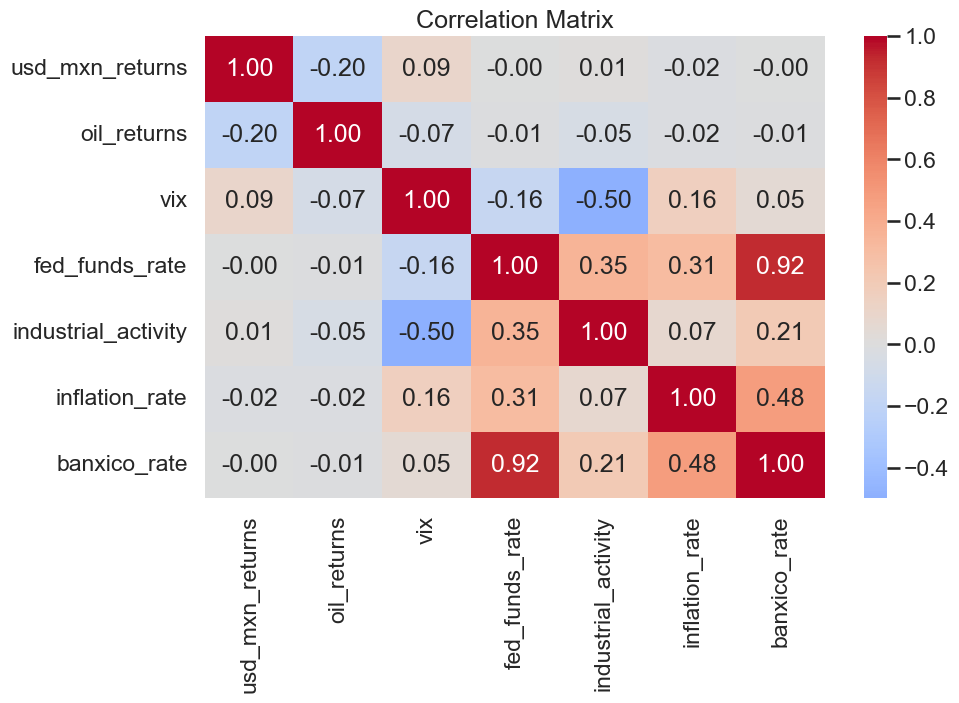

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

Note: 

1. Oil vs. USD/MXN ($\rho = -0.20$). A negative correlation means that when oil prices rise, the exchange rate drops (meaning you need fewer pesos to buy a dollar, which translates to a stronger/appreciating peso).The context: Although Mexico is no longer as dependent on oil as it was in the 1980s (thanks to manufacturing and remittances), Pemex and oil revenues remain a pillar of the country's public finances.

2. Fed Rate vs. Banxico Rate ($\rho = 0.92$). A correlation of $0.92$ is remarkably high (almost perfect). It means both central banks move practically in lockstep.The context: This is known as the "interest rate differential." If the US Federal Reserve (Fed) raises its interest rates and the Bank of Mexico (Banxico) stands still, investors would pull their capital out of Mexico and move it to the US (where it would be safer and yield higher returns). To prevent massive capital flight and a devaluation of the peso, Banxico almost always mirrors the Fed's moves.

3. VIX vs. Industrial Activity ($\rho = -0.50$).The VIX is widely known as Wall Street's "fear index." A negative correlation of $-0.50$ means that when global fear spikes, industrial production in Mexico drops.

### 4. Time Series Plot

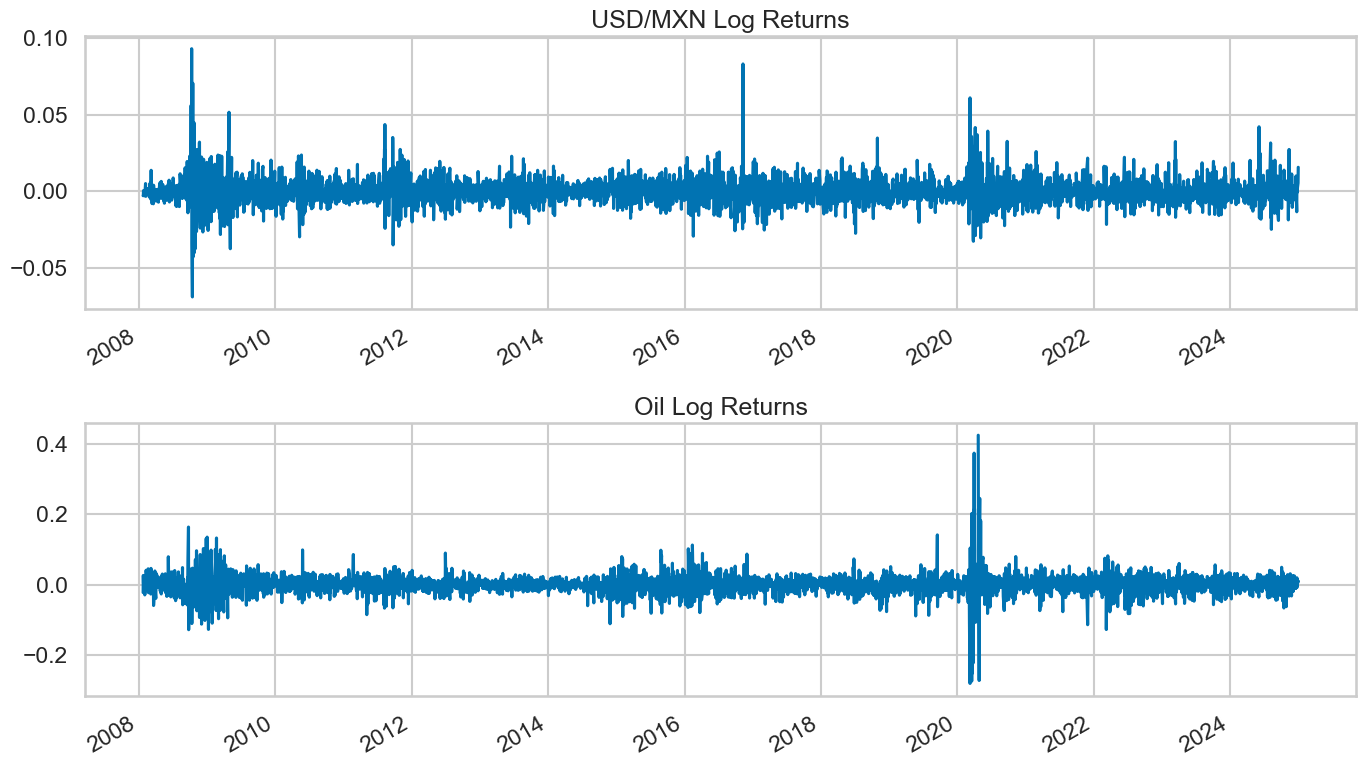

In [40]:
fig, ax = plt.subplots(2, 1, figsize=(14,8))

df_final["usd_mxn_returns"].plot(ax=ax[0])
ax[0].set_title("USD/MXN Log Returns")

df_final["oil_returns"].plot(ax=ax[1])
ax[1].set_title("Oil Log Returns")

plt.tight_layout()
plt.show()

Note:

The USD/MXN log returns fluctuate around zero with no clear trend, but periods of high volatility tend to cluster together, indicating volatility clustering. Several significant spikes can be observed during major economic events, including the 2008–2009 Global Financial Crisis, the 2016–2017 uncertainty surrounding the Trump election and NAFTA negotiations, and the COVID-19 shock in 2020.

The oil log returns display considerably higher volatility and more frequent extreme movements than the USD/MXN series. A particularly large spike occurs around 2020, corresponding to the COVID-19 pandemic oil market crash, when oil futures briefly traded at negative prices.

### 5. Distribution of Returns

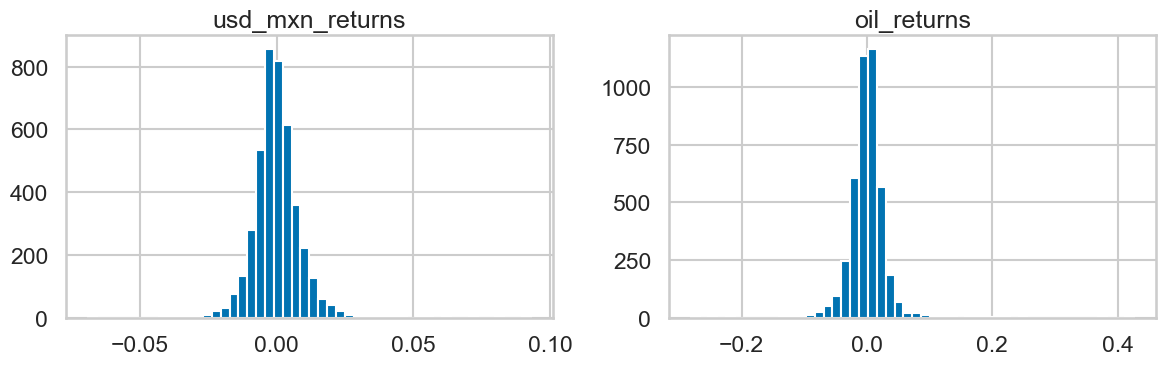

In [42]:
df_final[["usd_mxn_returns","oil_returns"]].hist(
    bins=50,
    figsize=(12,4)
)

plt.tight_layout()
plt.show()

The histograms show that both USD/MXN and oil returns are centered around zero, indicating that positive and negative returns tend to balance out over time. Most observations are concentrated near the mean, while the oil returns exhibit a wider dispersion, reflecting higher volatility compared to the exchange rate returns. Although the distributions resemble a bell shape, they appear to have heavier tails than a normal distribution, suggesting that extreme market movements occur more frequently than would be expected under normality. 

### 6. Skewness and Kurtosis

In [19]:
stats = pd.DataFrame({
    "skewness": df_final.skew(),
    "kurtosis": df_final.kurtosis()
})

stats

,skewness,kurtosis
mxn_returns,0.931178,10.520129
oil_returns,-0.160979,23.683403
vix,2.445100,8.646989
fed_funds_rate,1.521350,1.029628
industrial_activity,-1.334641,1.436264
inflation_rate,0.497578,-0.857612
banxico_rate,0.738983,-0.565709


The skewness values provide information about the asymmetry of the return distributions. USD/MXN returns exhibit a positive skewness of 0.93, indicating a moderately longer right tail and suggesting that large positive returns occur somewhat more frequently than large negative returns. In contrast, oil returns have a skewness of -0.16, which is very close to zero, indicating an approximately symmetric distribution with only a slight tendency toward larger negative returns. 

The kurtosis values reveal important information about the tail behavior of the distributions. Both USD/MXN returns (10.52) and oil returns (23.68) display kurtosis values far above those expected under a normal distribution, providing strong evidence of leptokurtosis and fat tails. This implies that extreme positive and negative returns occur much more frequently than predicted by normality assumptions. 

### 7. Volatility Clustering 

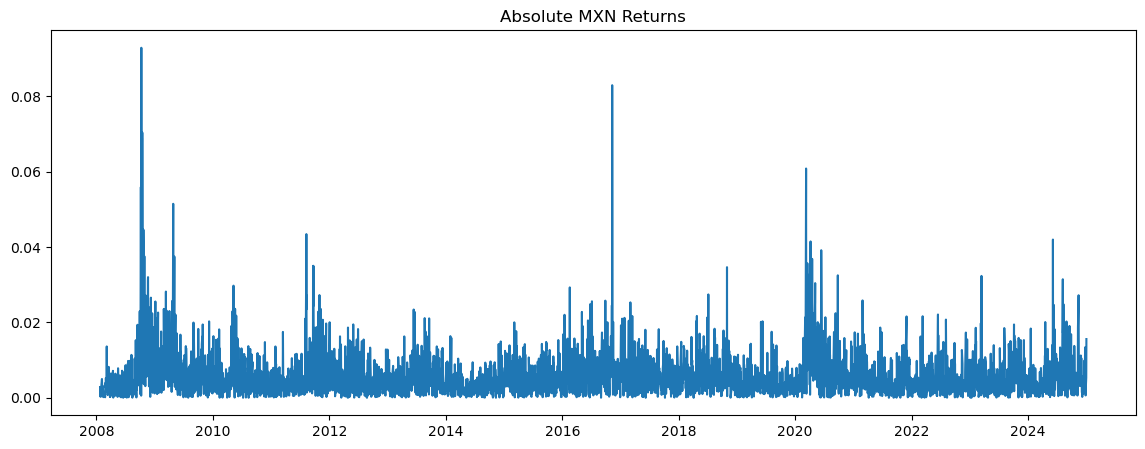

In [21]:
plt.figure(figsize=(14,5))

plt.plot(
    df_final.index,
    abs(df_final["mxn_returns"])    #Let's take the abosulute value. 
)

plt.title("Absolute MXN Returns")
plt.show()

The y-axis represents the absolute value of daily USD/MXN returns, which measures the magnitude of market movements regardless of direction. Higher values indicate larger daily fluctuations, while lower values correspond to relatively stable market conditions. The figure shows that periods of large return magnitudes tend to occur in clusters, particularly during major market events such as the 2008–2009 Global Financial Crisis and the COVID-19 shock in 2020.

### 8.Detecting changepoints in time series- 2020 as year reference

The CUSUM(cumulative sum) method is used to detect shifts of the means in a time series. 

1. Take 2020 as a year reference. 

In [54]:
df_change_point = df_final.loc["2020-01-01":"2020-12-31"].copy()

df_change_point = df_change_point[["mxn_usd"]].reset_index()

df_change_point.columns = ["time", "price"]

df_change_point.head()

,time,price
0,2020-01-02,18.898800
1,2020-01-03,18.830299
2,2020-01-06,18.944759
3,2020-01-07,18.841450
4,2020-01-08,18.964199


2. Import libraries

In [57]:
!pip install ruptures

  Obtaining dependency information for ruptures from https://files.pythonhosted.org/packages/ae/ea/b561e98a69e412c29a808cdb25acff73005b26d0313632b7ec29a5846f8c/ruptures-1.1.10-cp311-cp311-macosx_10_9_x86_64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 497.0/497.0 kB 1.9 MB/s eta 0:00:00a 0:00:01m


In [60]:
import ruptures as rpt

import numpy as np

import matplotlib.pyplot as plt

3. Get a format for ruptures

In [67]:
signal = df_change_point["price"].values

4. Ejecuta el detector

In [73]:
algo = rpt.Pelt(model="rbf").fit(signal)

breaks = algo.predict(pen=10)

print(breaks)

[50, 100, 215, 252]


5. Graph 

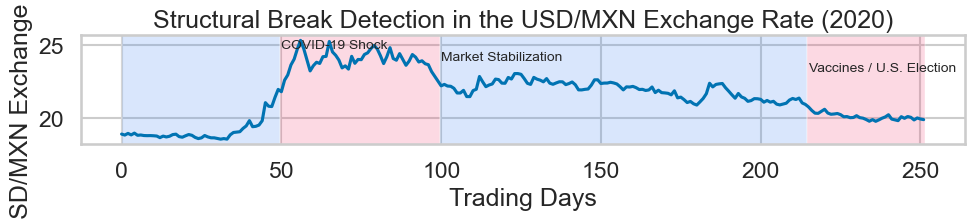

In [79]:
rpt.display(signal, breaks)

plt.title("Structural Break Detection in the USD/MXN Exchange Rate (2020)")
plt.xlabel("Trading Days")
plt.ylabel("USD/MXN Exchange Rate")

# Anotaciones económicas
plt.text(50, 24.8, "COVID-19 Shock", fontsize=10)
plt.text(100, 24.0, "Market Stabilization", fontsize=10)
plt.text(215, 23.2, "Vaccines / U.S. Election", fontsize=10)

plt.show()

### 9. Jarque-Bera test 

In [84]:
!pip install scipy

In [87]:
from scipy.stats import jarque_bera

In [89]:
jb_stat, jb_pvalue = jarque_bera(
    df_final["usd_mxn_returns"].dropna()
)

results = pd.DataFrame({
    "Statistic": [jb_stat],
    "P-value": [jb_pvalue]
})

results

,Statistic,P-value
0,20128.86632,0.0


Note: The Jarque-Bera test strongly rejects the null hypothesis of normality (JB = 20,128.87, p < 0.001). This indicates that the distribution of USD/MXN returns significantly deviates from a Gaussian distribution.